<a href="https://colab.research.google.com/github/AleAfonsodeCarvalho/datathon_fiap_passos_magicos/blob/main/01_analise_dados_datathon_fiap_passos_magicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PÓS-TECH FIAP — DATA ANALYTICS
Projeto: Mentor Digital – Sistema Preditivo de Risco de Defasagem
Entidade: Associação Passos Mágicos
Fase 5: Deep Learning and Unstructured Data

Data: 08 de março de 2026

Aluno: Alexandre Afonso de Carvalho

RM: 358820 | Turma: 9DTAT

**Primeira parte:**
Trabalhando as bases de dados

In [1]:
# ==============================================================================
# PÓS-TECH FIAP - DATA ANALYTICS
# ==============================================================================
# PROJETO: Mentor Digital - Sistema Preditivo de Risco de Defasagem
# ENTIDADE: Associação Passos Mágicos
# ------------------------------------------------------------------------------
# FASE 5: Deep Learning and Unstructured Data
# DATA: 08 de março de 2026
#
# ALUNO: Alexandre Afonso de Carvalho
# RM: 358820
# TURMA: 9DTAT
# ==============================================================================

import pandas as pd
import numpy  as np

# Função para converter vígula para ponto decimal
def clean_numeric(series):
    return pd.to_numeric(series.astype(str).str.replace(',', '.'), errors='coerce')

#Carregando os arquivos com o separador correto
df22 = pd.read_csv('/content/sample_data/pede_2022.csv', sep=';')
df23 = pd.read_csv('/content/sample_data/pede_2023.csv', sep=';')
df24 = pd.read_csv('/content/sample_data/pede_2024.csv', sep=';')

#Padronização Rigorosa de Colunas
df22.rename(columns={'Defas': 'DEFASAGEM', 'Matem': 'MAT', 'Portug': 'POR', 'Inglês': 'ING'}, inplace=True)
# 2023 e 2024 (Atenção ao 'D' maiúsculo de Defasagem)
df23.rename(columns={'Defasagem': 'DEFASAGEM', 'Mat': 'MAT', 'Por': 'POR', 'Ing': 'ING'}, inplace=True)
df24.rename(columns={'Defasagem': 'DEFASAGEM', 'Mat': 'MAT', 'Por': 'POR', 'Ing': 'ING'}, inplace=True)

#Unificação dos Indicadores Principais

df22['INDE'] = clean_numeric(df22['INDE 22'])
df23['INDE'] = clean_numeric(df23['INDE 2023'])
df24['INDE'] = clean_numeric(df24['INDE 2024'])

# Adicionando o ano de referência
df22['ANO_REF'] = 2022
df23['ANO_REF'] = 2023
df24['ANO_REF'] = 2024

df_base = pd.concat([df22, df23, df24], ignore_index=True)

# Limpando os indicadores (removendo vírgulas e convertendo para número)
cols_numericas = ['IDA', 'IEG', 'IPS', 'IPP', 'IPV', 'IAN', 'DEFASAGEM', 'MAT', 'POR']
for col in cols_numericas:
    if col in df_base.columns:
        df_base[col] = clean_numeric(df_base[col])

# TRATAMENTO DE NULOS:

df_base['IPP'] = df_base['IPP'].fillna(df_base['IPP'].mean())
df_base[cols_numericas] = df_base[cols_numericas].fillna(df_base[cols_numericas].mean())
print(f"Base consolidada! Total de registros: {len(df_base)}")

Base consolidada! Total de registros: 3031


**Segunda Parte:** Analise dos dados

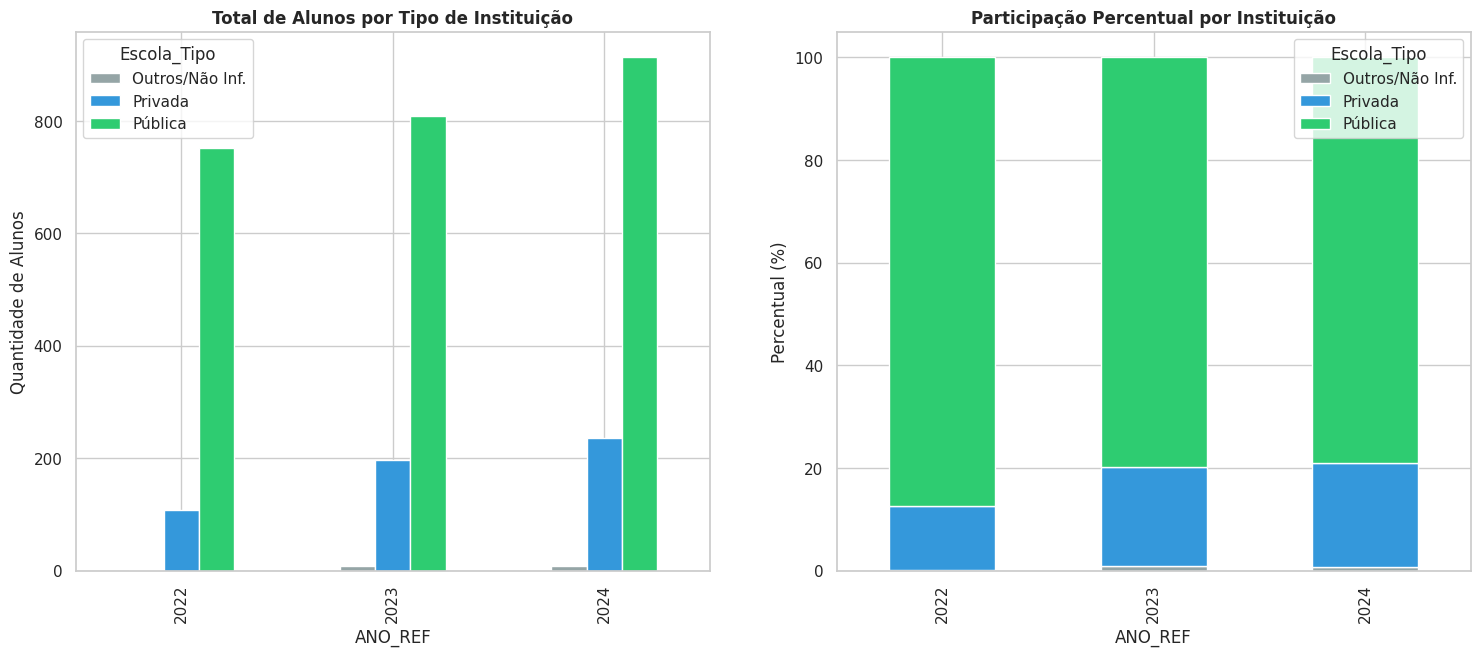

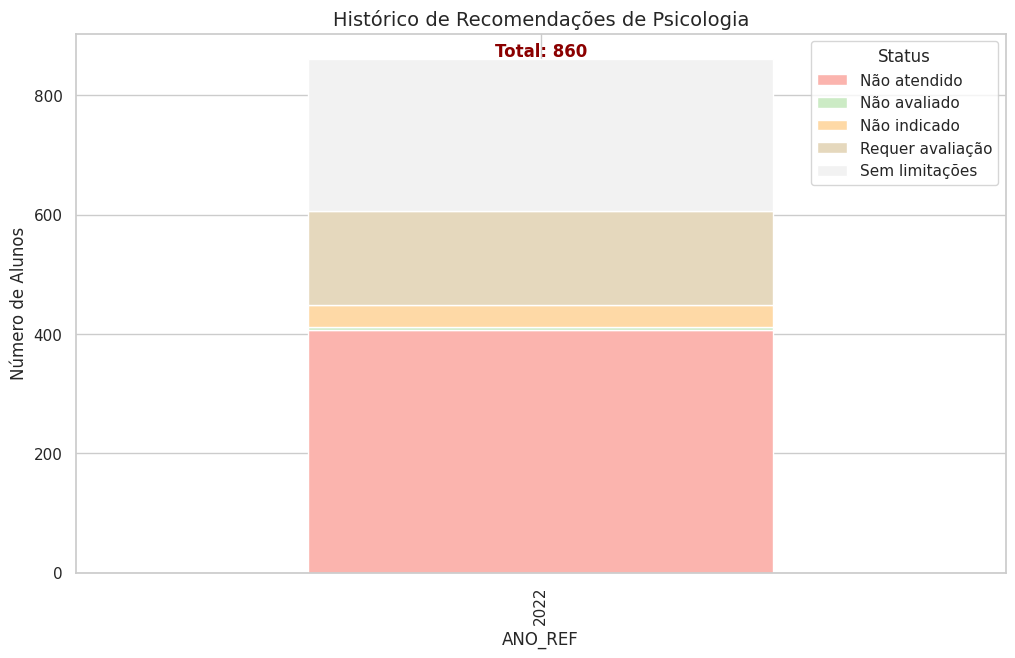

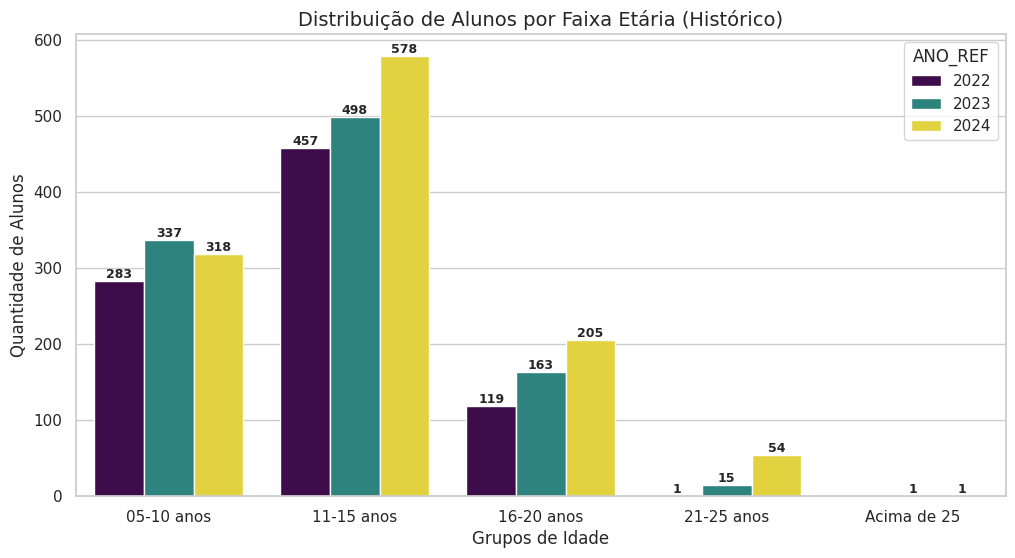

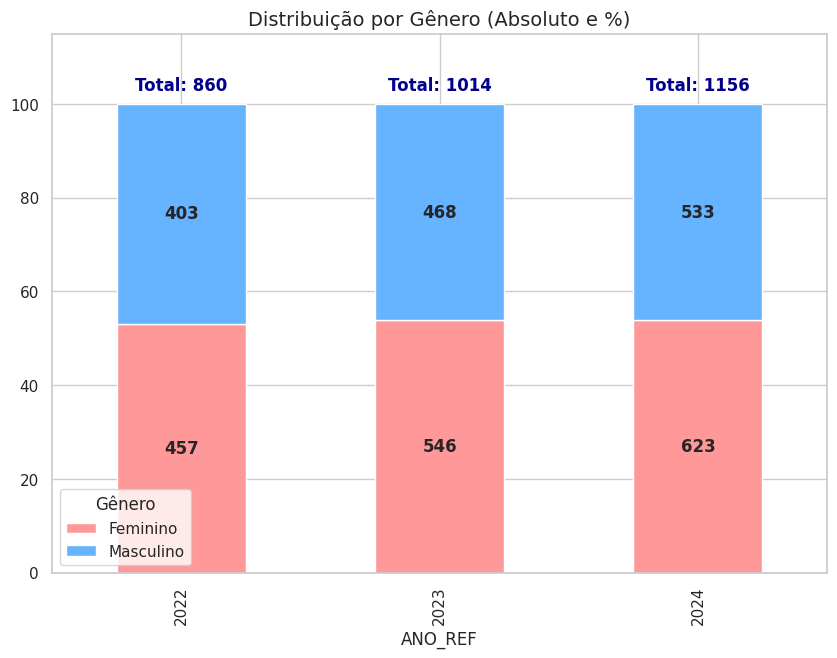

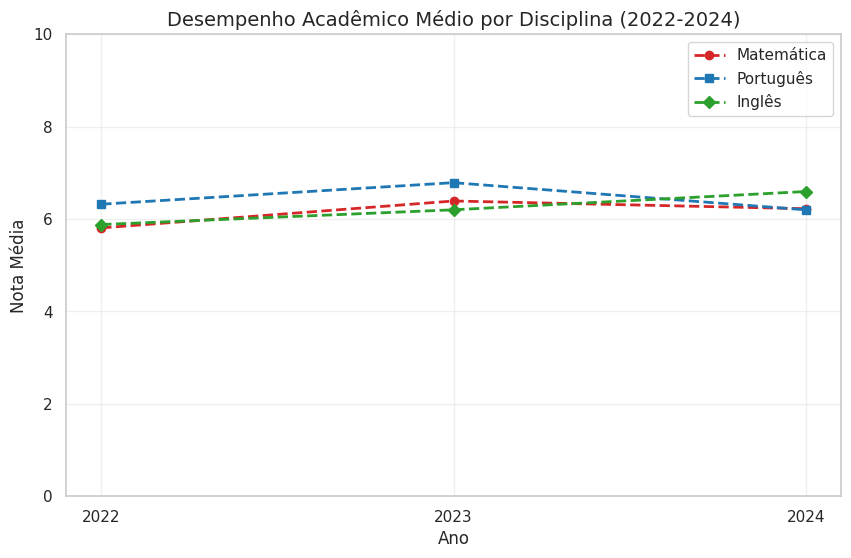

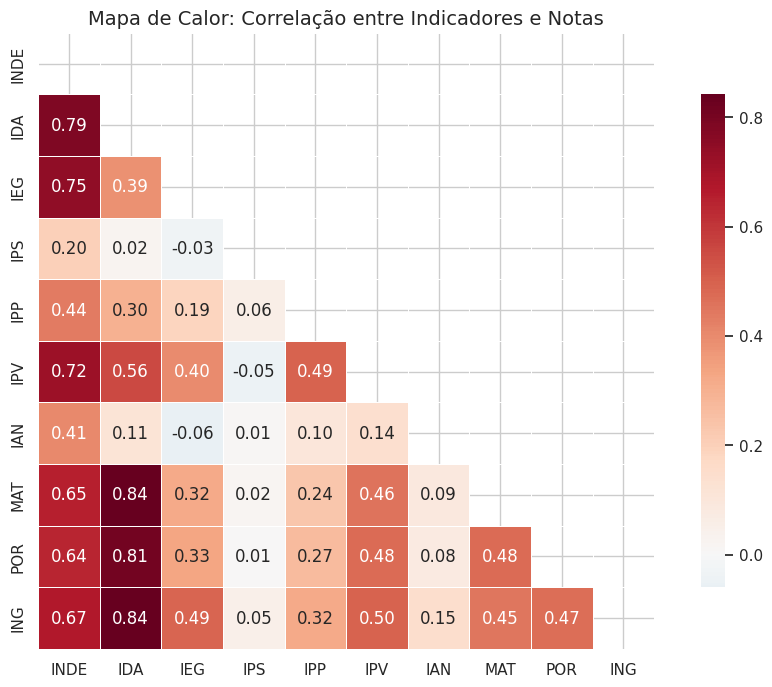

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

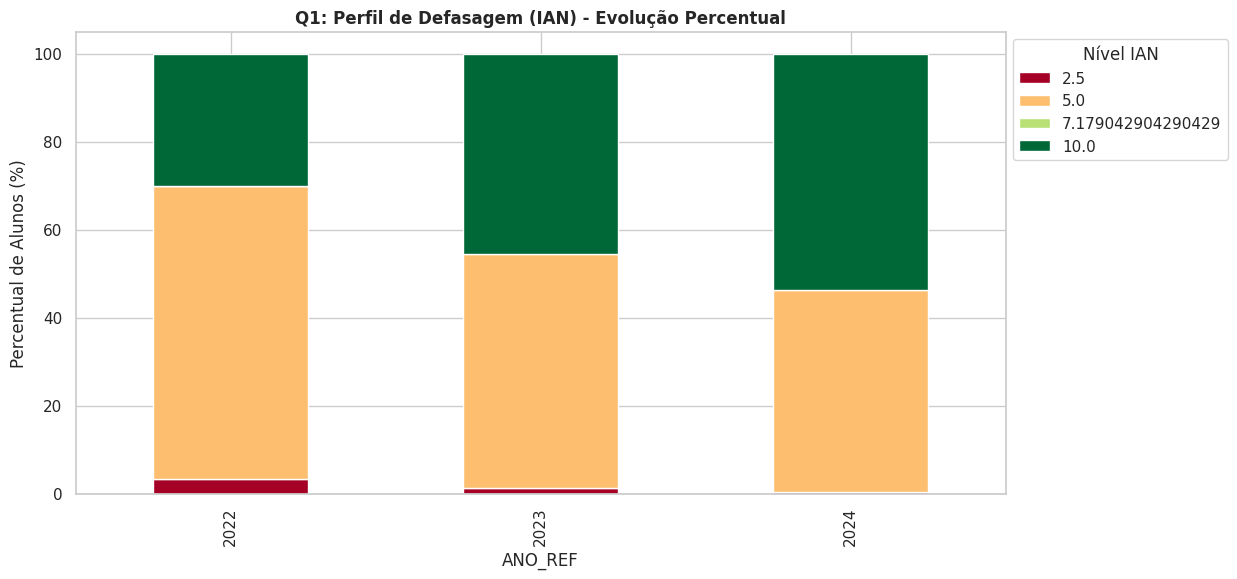

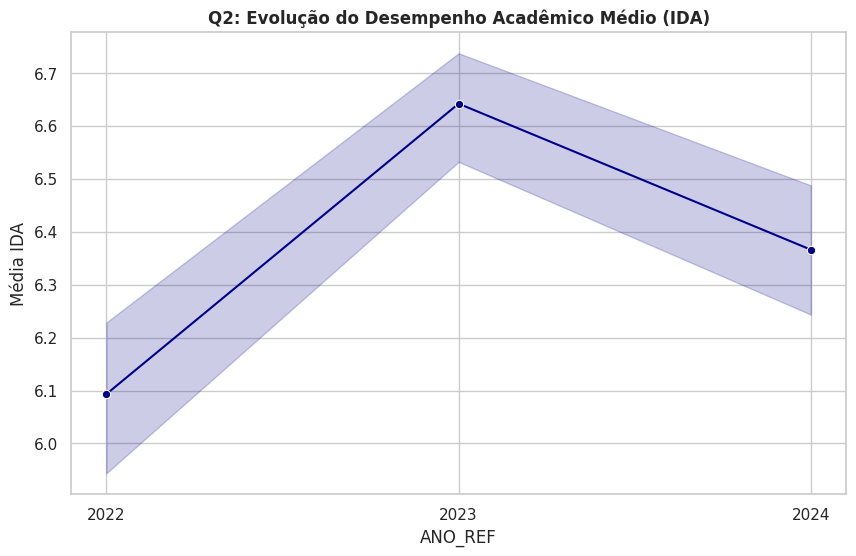

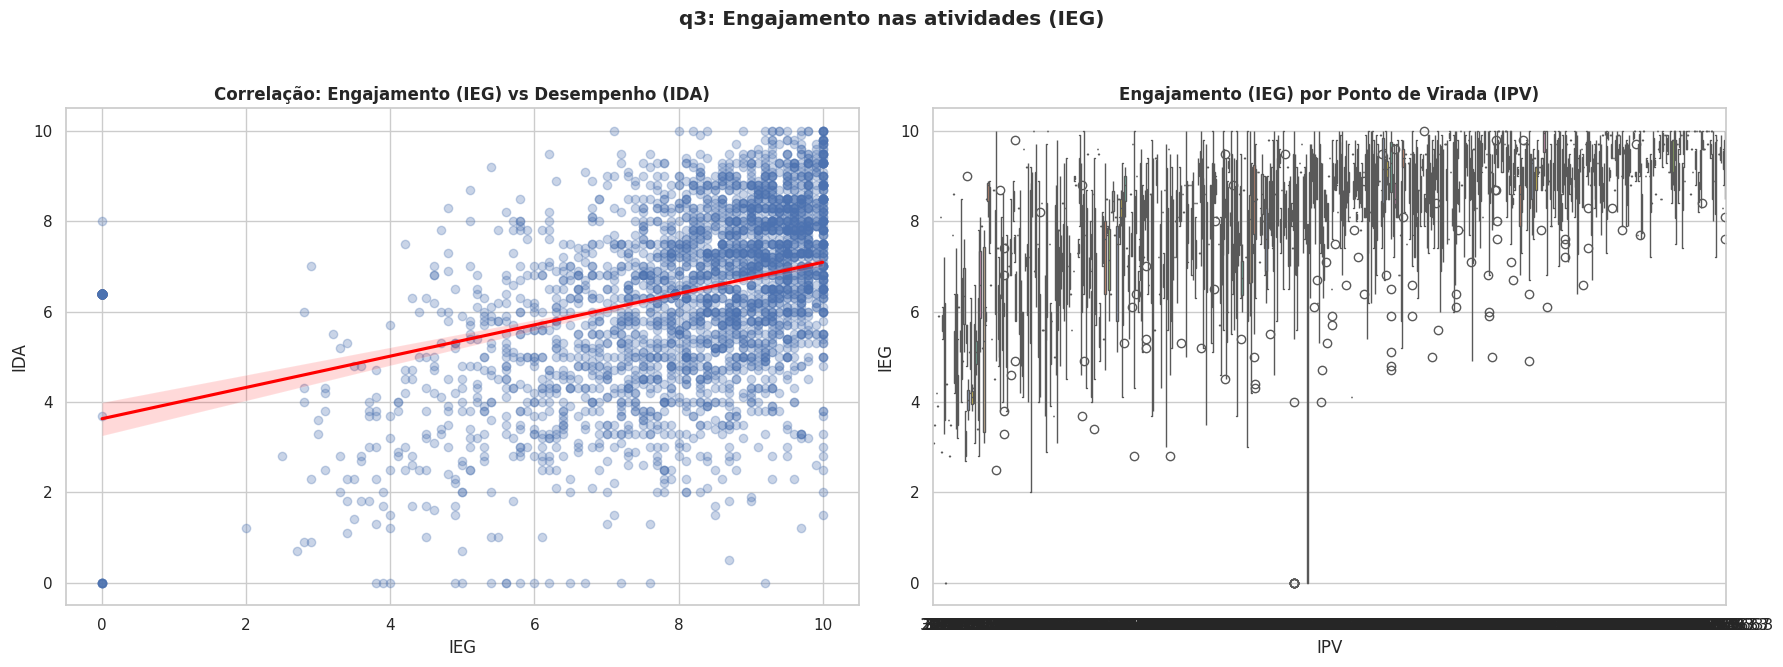

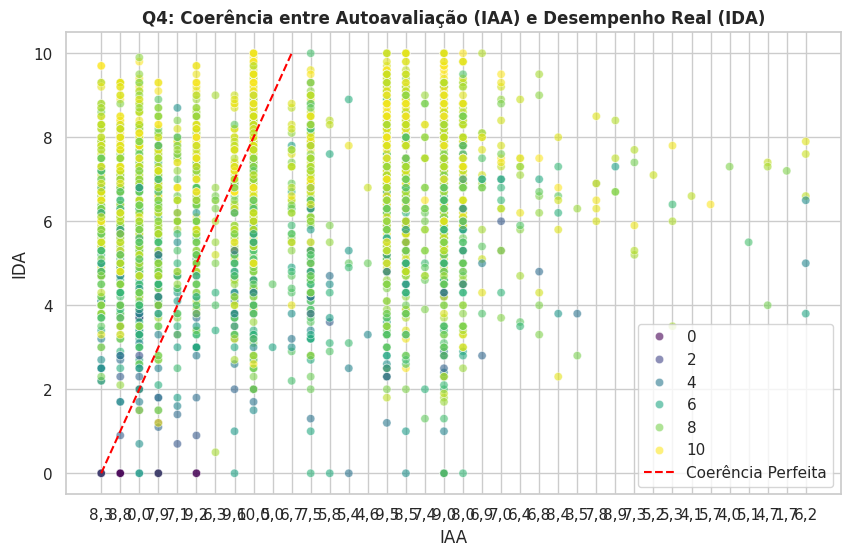

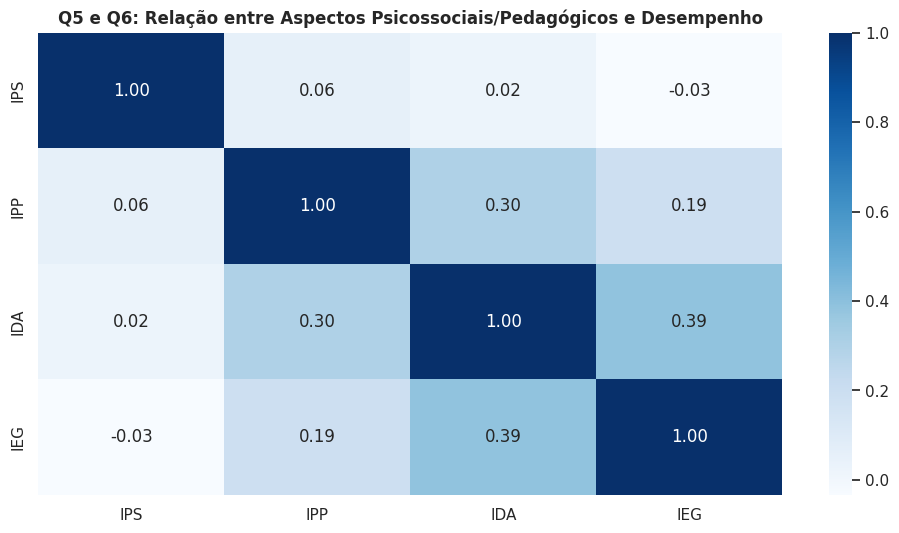

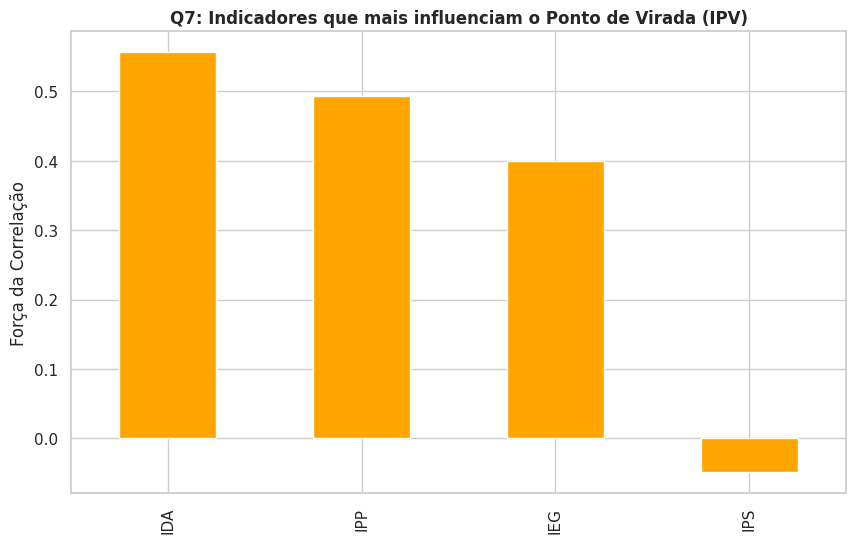

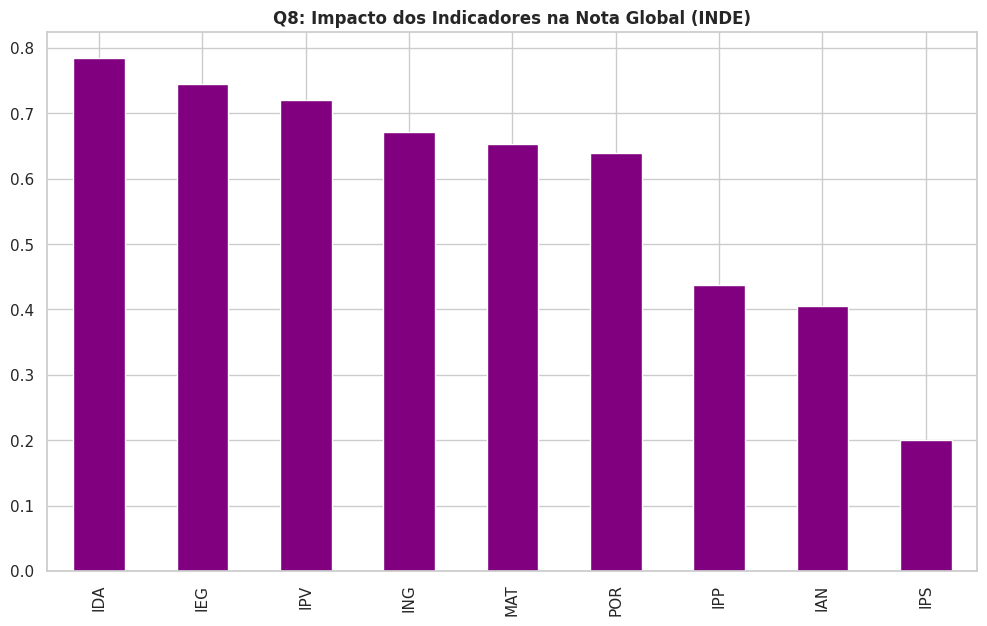

<Figure size 1200x600 with 0 Axes>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)


def clean_numeric(series):
    return pd.to_numeric(series.astype(str).str.replace(',', '.'), errors='coerce')

def clean_idade(val):
    val = str(val)
    if '/' in val:
        return int(val.split('/')[0])
    try:
        return int(float(val))
    except:
        return np.nan

# Gênero
genero_map = {'Menina': 'Feminino', 'Menino': 'Masculino', 'Feminino': 'Feminino', 'Masculino': 'Masculino'}
df_base['Gênero'] = df_base['Gênero'].map(genero_map)

# Instituição de Ensino (Agrupamento)
def map_escola(x):
    x = str(x).lower()
    if 'pública' in x: return 'Pública'
    if 'privada' in x or 'decisão' in x or 'jp ii' in x or 'bolsista' in x: return 'Privada'
    return 'Outros/Não Inf.'

df_base['Escola_Tipo'] = df_base['Instituição de ensino'].apply(map_escola)

# Idade e Faixa Etária
df_base['Idade_Clean'] = df_base['Idade 22'].combine_first(df_base['Idade']).apply(clean_idade)
bins = [5, 10, 15, 20, 25, 100]
labels = ['05-10 anos', '11-15 anos', '16-20 anos', '21-25 anos', 'Acima de 25']
df_base['Faixa_Etaria'] = pd.cut(df_base['Idade_Clean'], bins=bins, labels=labels)

# Indicadores Numéricos
indicadores_finais = ['INDE', 'IDA', 'IEG', 'IPS', 'IPP', 'IPV', 'IAN', 'MAT', 'POR', 'ING']
for col in indicadores_finais:
    if col in df_base.columns:
        df_base[col] = clean_numeric(df_base[col])

# --- 3. GRÁFICO: INSTITUIÇÃO DE ENSINO (ABSOLUTO E PERCENTUAL) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Absoluto
inst_ano = df_base.groupby(['ANO_REF', 'Escola_Tipo']).size().unstack().fillna(0)
inst_ano.plot(kind='bar', ax=ax1, color=['#95a5a6', '#3498db', '#2ecc71'])
ax1.set_title('Total de Alunos por Tipo de Instituição', fontweight='bold')
ax1.set_ylabel('Quantidade de Alunos')

# Percentual
inst_pct = inst_ano.div(inst_ano.sum(axis=1), axis=0) * 100
inst_pct.plot(kind='bar', stacked=True, ax=ax2, color=['#95a5a6', '#3498db', '#2ecc71'])
ax2.set_title('Participação Percentual por Instituição', fontweight='bold')
ax2.set_ylabel('Percentual (%)')
plt.show()

# --- 4. GRÁFICO: REC PSICOLOGIA (HISTÓRICO EMPILHADO) ---
plt.figure(figsize=(12, 7))
psic_ano = df_base.groupby(['ANO_REF', 'Rec Psicologia']).size().unstack().fillna(0)
ax = psic_ano.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='Pastel1')

for i, (ano, row) in enumerate(psic_ano.iterrows()):
    total = row.sum()
    if total > 0:
        plt.text(i, total + 5, f'Total: {int(total)}', ha='center', fontweight='bold', color='darkred')

plt.title('Histórico de Recomendações de Psicologia', fontsize=14)
plt.ylabel('Número de Alunos')
plt.legend(title='Status', bbox_to_anchor=(1, 1))
plt.show()

# --- 5. GRÁFICO: IDADE (FAIXA ETÁRIA CONSOLIDADA) ---
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_base, x='Faixa_Etaria', hue='ANO_REF', palette='viridis')
plt.title('Distribuição de Alunos por Faixa Etária (Histórico)', fontsize=14)
plt.ylabel('Quantidade de Alunos')
plt.xlabel('Grupos de Idade')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.show()

# --- 6. GRÁFICO: GÊNERO ---
plt.figure(figsize=(10, 7))
genero_ano = df_base.groupby(['ANO_REF', 'Gênero']).size().unstack().fillna(0)
genero_pct = genero_ano.div(genero_ano.sum(axis=1), axis=0) * 100
ax = genero_pct.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=plt.gca())

for i, (ano, row) in enumerate(genero_ano.iterrows()):
    cum_height = 0
    total_alunos = row.sum()
    for genero in genero_ano.columns:
        valor_absoluto = int(row[genero])
        porcentagem = (valor_absoluto / total_alunos) * 100
        if valor_absoluto > 0:
            ax.text(i, cum_height + (porcentagem / 2), str(valor_absoluto), ha='center', va='center', fontweight='bold')
            cum_height += porcentagem
    ax.text(i, 102, f'Total: {int(total_alunos)}', ha='center', va='bottom', fontweight='bold', color='darkblue')

plt.title('Distribuição por Gênero (Absoluto e %)', fontsize=14)
plt.ylim(0, 115)
plt.show()

# --- 7. VISUALIZAÇÃO B: ANO DE INGRESSO ---

medias_disc = df_base.groupby('ANO_REF')[['MAT', 'POR', 'ING']].mean()

plt.figure(figsize=(10, 6))
plt.plot(medias_disc.index, medias_disc['MAT'], marker='o', ls='--', lw=2, label='Matemática', color='#d62728')
plt.plot(medias_disc.index, medias_disc['POR'], marker='s', ls='--', lw=2, label='Português', color='#1f77b4')
plt.plot(medias_disc.index, medias_disc['ING'], marker='D', ls='--', lw=2, label='Inglês', color='#2ca02c')

plt.title('Desempenho Acadêmico Médio por Disciplina (2022-2024)', fontsize=14)
plt.xlabel('Ano')
plt.ylabel('Nota Média')
plt.xticks([2022, 2023, 2024])

plt.ylim(0, 10)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- 8. VISUALIZAÇÃO D: HEATMAP DE CORRELAÇÃO ---
plt.figure(figsize=(12, 8))

corr = df_base[indicadores_finais].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', center=0,

            square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Mapa de Calor: Correlação entre Indicadores e Notas', fontsize=14)

# --- 9. ANÁLISE DAS 10 QUESTÕES DO DESAFIO ---

# Questão 9: PREVISÃO DE RISCO (AQUI VOCÊ USARIA O MODELO TREINADO)
# Exemplo de visualização da importância das variáveis (Feature Importance)
if 'model' in locals():
    plt.figure(figsize=(10, 6))
    importancias = pd.Series(model.feature_importances_, index=features)
    importancias.sort_values().plot(kind='barh', color='skyblue')
    plt.title('Q9: Padrões Preditores de Risco (Importância de Variáveis)', fontweight='bold')
    plt.show()

# Questão 10: EFETIVIDADE DO PROGRAMA (POR FASE)
plt.figure(figsize=(12, 6))
# Verificando se o INDE aumenta conforme o aluno avança nas fases
# Nota: Certifique-se que a coluna de fases existe (ex: 'Pedra' ou 'Fase')
if 'Pedra' in df_base.columns:
    ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio', 'Brilhante']
    sns.boxplot(data=df_base, x='Pedra', y='INDE', order=[p for p in ordem_pedras if p in df_base['Pedra'].unique()])
    plt.title('Q10: Efetividade do Programa - Evolução do INDE por Fase', fontweight='bold')

plt.show()

# Questão 10: EFETIVIDADE DO PROGRAMA (POR FASE)
plt.figure(figsize=(12, 6))
# Verificando se o INDE aumenta conforme o aluno avança nas fases
# Nota: Certifique-se que a coluna de fases existe (ex: 'Pedra' ou 'Fase')
if 'Pedra' in df_base.columns:
    ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio', 'Brilhante']
    sns.boxplot(data=df_base, x='Pedra', y='INDE', order=[p for p in ordem_pedras if p in df_base['Pedra'].unique()])
    plt.title('Q10: Efetividade do Programa - Evolução do INDE por Fase', fontweight='bold')

plt.show()

# Questão 1: ADEQUAÇÃO DO NÍVEL (IAN) - Evolução da Defasagem
plt.figure(figsize=(12, 6))
ian_evolucao = df_base.groupby(['ANO_REF', 'IAN']).size().unstack().fillna(0)
# Calculando percentual para ver a evolução da melhoria
ian_pct = ian_evolucao.div(ian_evolucao.sum(axis=1), axis=0) * 100
ax = ian_pct.plot(kind='bar', stacked=True, ax=plt.gca(), cmap='RdYlGn')
plt.title('Q1: Perfil de Defasagem (IAN) - Evolução Percentual', fontweight='bold')
plt.ylabel('Percentual de Alunos (%)')
plt.legend(title='Nível IAN', bbox_to_anchor=(1, 1))
plt.show()

# Questão 2: DESEMPENHO ACADÊMICO (IDA) - Tendência
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_base, x='ANO_REF', y='IDA', marker='o', estimator='mean', color='darkblue', errorbar=('ci', 95))
plt.title('Q2: Evolução do Desempenho Acadêmico Médio (IDA)', fontweight='bold')
plt.ylabel('Média IDA')
plt.xticks([2022, 2023, 2024])
plt.show()

# Questão 3: Ajustado para evitar o FutureWarning
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# TÍTULO PRINCIPAL (Geral para a figura toda)
fig.suptitle('q3: Engajamento nas atividades (IEG)', fontweight='bold')

# Gráfico 1: Regressão
sns.regplot(data=df_base, x='IEG', y='IDA', ax=ax1, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
ax1.set_title('Correlação: Engajamento (IEG) vs Desempenho (IDA)', fontweight='bold')

# Gráfico 2: Boxplot
sns.boxplot(data=df_base, x='IPV', y='IEG', ax=ax2, hue='IPV', palette='Set2', legend=False)
ax2.set_title('Engajamento (IEG) por Ponto de Virada (IPV)', fontweight='bold')

# Ajusta o layout para o título não sobrepor os eixos
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Questão 4: AUTOAVALIAÇÃO (IAA) vs REALIDADE (IDA/IEG)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_base, x='IAA', y='IDA', hue='IEG', palette='viridis', alpha=0.6)
plt.plot([0, 10], [0, 10], color='red', linestyle='--', label='Coerência Perfeita')
plt.title('Q4: Coerência entre Autoavaliação (IAA) e Desempenho Real (IDA)', fontweight='bold')
plt.legend()
plt.show()

# Questão 5 e 6: ASPECTOS PSICOSSOCIAIS (IPS) E PSICOPEDAGÓGICOS (IPP)
plt.figure(figsize=(12, 6))
# Analisando se IPS baixo precede quedas (usando correlação)
cols_psico = ['IPS', 'IPP', 'IDA', 'IEG']
sns.heatmap(df_base[cols_psico].corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Q5 e Q6: Relação entre Aspectos Psicossociais/Pedagógicos e Desempenho', fontweight='bold')
plt.show()

# Questão 7: PONTO DE VIRADA (IPV) - O que mais influencia?
# Calculando a correlação das variáveis com o IPV (considerando IPV como numérico 0/1 se necessário)
# Se o seu IPV for categórico 'Sim'/'Não', transformamos temporariamente para correlação:
df_temp = df_base.copy()
if df_temp['IPV'].dtype == 'O':
    df_temp['IPV_num'] = df_temp['IPV'].map({'Sim': 1, 'Não': 0})
else:
    df_temp['IPV_num'] = df_temp['IPV']

correl_ipv = df_temp[['IDA', 'IEG', 'IPS', 'IPP', 'IPV_num']].corr()['IPV_num'].sort_values(ascending=False).drop('IPV_num')
plt.figure(figsize=(10, 6))
correl_ipv.plot(kind='bar', color='orange')
plt.title('Q7: Indicadores que mais influenciam o Ponto de Virada (IPV)', fontweight='bold')
plt.ylabel('Força da Correlação')
plt.show()

# Questão 8: MULTIDIMENSIONALIDADE (Nota Global INDE)
plt.figure(figsize=(12, 7))
# O Heatmap que você já tem no item 6 do seu código já responde bem a isso,
# mas aqui focamos na nota global:
inde_corr = df_base[indicadores_finais].corr()['INDE'].sort_values(ascending=False).drop('INDE')
inde_corr.plot(kind='bar', color='purple')
plt.title('Q8: Impacto dos Indicadores na Nota Global (INDE)', fontweight='bold')
plt.show()

# Questão 9: PREVISÃO DE RISCO (AQUI VOCÊ USARIA O MODELO TREINADO)
# Exemplo de visualização da importância das variáveis (Feature Importance)
if 'model' in locals():
    plt.figure(figsize=(10, 6))
    importancias = pd.Series(model.feature_importances_, index=features)
    importancias.sort_values().plot(kind='barh', color='skyblue')
    plt.title('Q9: Padrões Preditores de Risco (Importância de Variáveis)', fontweight='bold')
    plt.show()

# Questão 10: EFETIVIDADE DO PROGRAMA (POR FASE)
plt.figure(figsize=(12, 6))
# Verificando se o INDE aumenta conforme o aluno avança nas fases
# Nota: Certifique-se que a coluna de fases existe (ex: 'Pedra' ou 'Fase')
if 'Pedra' in df_base.columns:
    ordem_pedras = ['Quartzo', 'Ágata', 'Ametista', 'Topázio', 'Brilhante']
    sns.boxplot(data=df_base, x='Pedra', y='INDE', order=[p for p in ordem_pedras if p in df_base['Pedra'].unique()])
    plt.title('Q10: Efetividade do Programa - Evolução do INDE por Fase', fontweight='bold')

plt.show()

**Terceira Parte:** Preparando o modelo

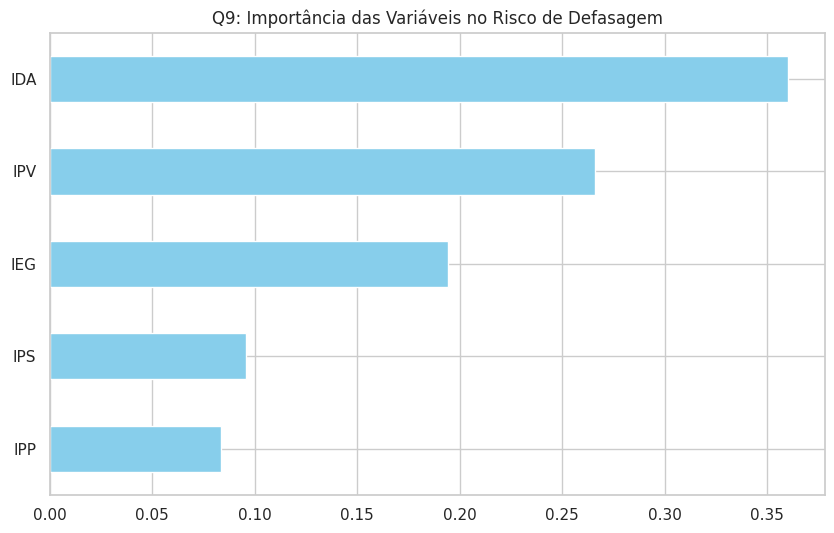

In [3]:

# 1. Definir o Alvo (y) - Exemplo: Alunos com INDE abaixo da mediana são 'Risco'
mediana_inde = df_base['INDE'].median()
df_base['RISCO'] = (df_base['INDE'] < mediana_inde).astype(int)

# 2. Definir as Features (X)
features_modelo = ['IDA', 'IEG', 'IPS', 'IPP', 'IPV']
X = df_base[features_modelo].fillna(df_base[features_modelo].median())
y = df_base['RISCO']

# 3. Treinar
from sklearn.ensemble import RandomForestClassifier
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X, y)

plt.figure(figsize=(10, 6))
importancias = pd.Series(modelo.feature_importances_, index=features_modelo)
importancias.sort_values().plot(kind='barh', color='skyblue')
plt.title('Q9: Importância das Variáveis no Risco de Defasagem')
plt.show()

**Quarta Parte:** Previsão de Risco

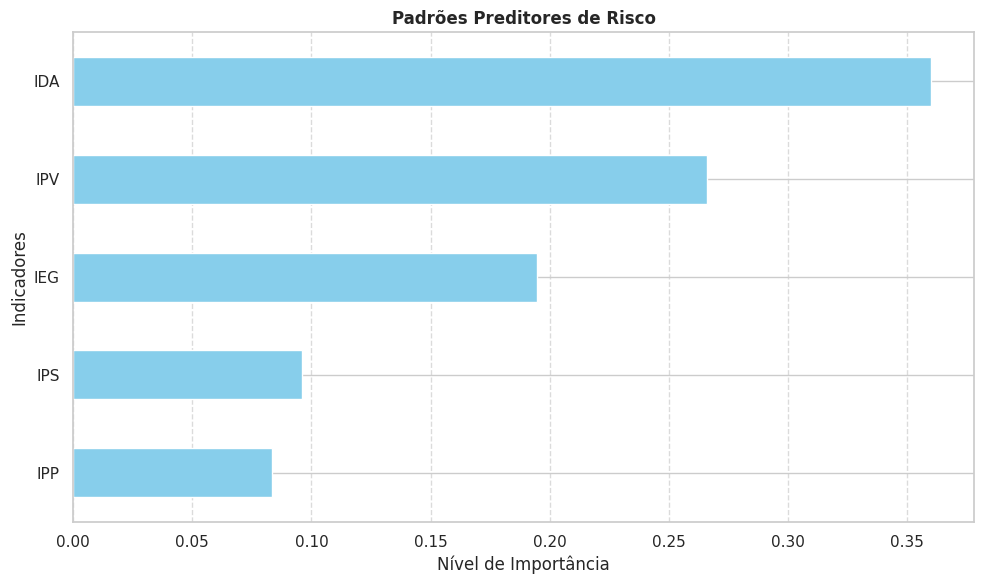

In [4]:
#PREVISÃO DE RISCO
# Verificando se a variável 'modelo' existe (ajustado para o nome que usamos no treino)
if 'modelo' in locals():
    plt.figure(figsize=(10, 6))

    importancias = pd.Series(modelo.feature_importances_, index=X.columns)

    # Gerando o gráfico de barras horizontais
    importancias.sort_values().plot(kind='barh', color='skyblue')

    plt.title('Padrões Preditores de Risco', fontweight='bold')
    plt.xlabel('Nível de Importância')
    plt.ylabel('Indicadores')
    plt.grid(axis='x', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
else:
    print("Erro: Certifique-se de rodar a célula de treinamento primeiro!")

**Quarta parte:** Estabilidade do modelo

Registros prontos para o modelo: 3031

--- Resultado do Modelo ---
              precision    recall  f1-score   support

           0       0.54      0.42      0.47       265
           1       0.62      0.72      0.67       342

    accuracy                           0.59       607
   macro avg       0.58      0.57      0.57       607
weighted avg       0.58      0.59      0.58       607



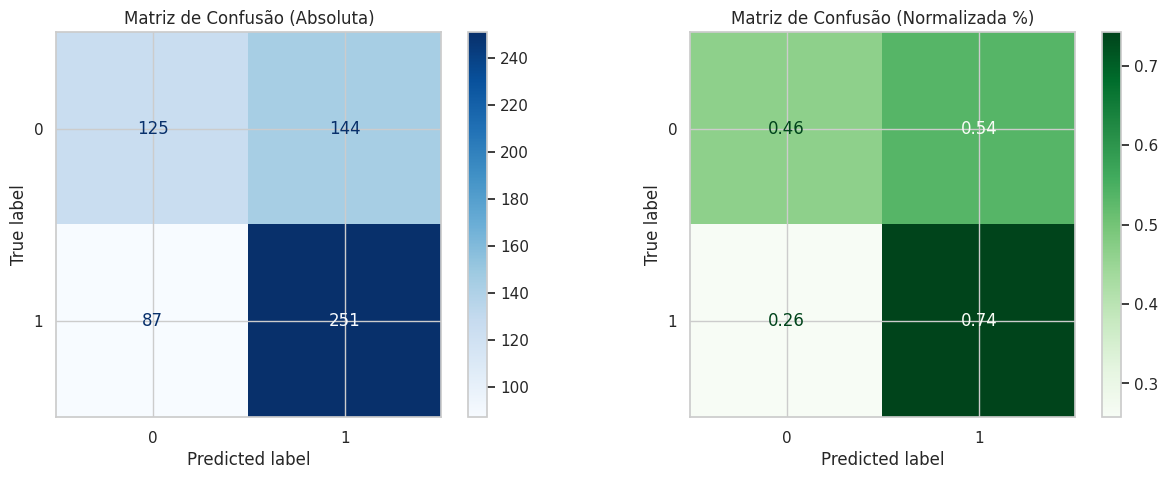


RELATÓRIO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

 Estável (0)       0.59      0.46      0.52       269
   Risco (1)       0.64      0.74      0.68       338

    accuracy                           0.62       607
   macro avg       0.61      0.60      0.60       607
weighted avg       0.62      0.62      0.61       607



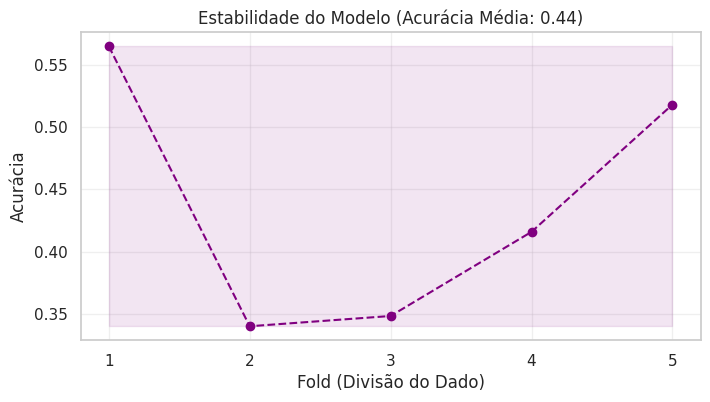

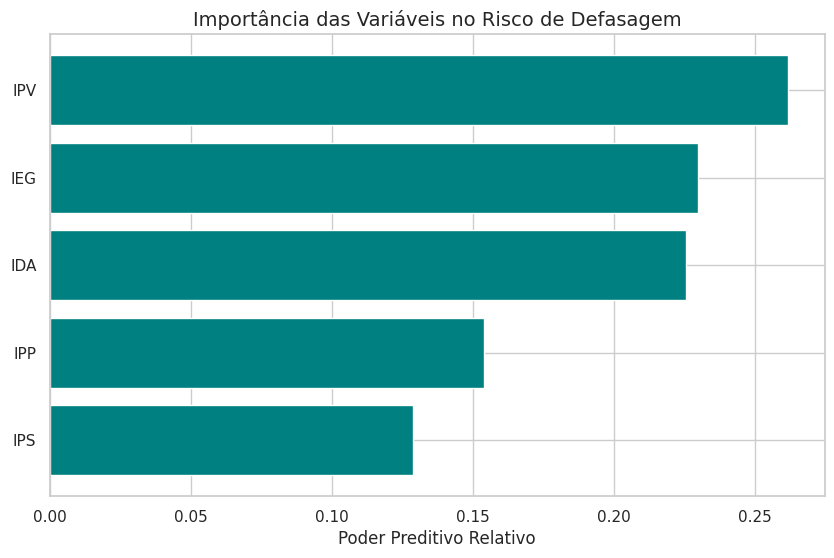

In [5]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Criamos o Target: 1 se o aluno está defasado (DEFASAGEM < 0), 0 se não.
df_model = df_base[['IDA', 'IEG', 'IPS', 'IPP', 'IPV', 'DEFASAGEM']].copy()
df_model['TARGET_RISCO'] = (df_model['DEFASAGEM'] < 0).astype(int)

# Removendo apenas as linhas onde o alvo ou preditores ainda sejam NaN (após o preenchimento acima)
df_model = df_model.dropna()

print(f"Registros prontos para o modelo: {len(df_model)}")

if len(df_model) > 0:
    X = df_model[['IDA', 'IEG', 'IPS', 'IPP', 'IPV']]
    y = df_model['TARGET_RISCO']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    modelo = RandomForestClassifier(n_estimators=100, random_state=42)
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    print("\n--- Resultado do Modelo ---")
    print(classification_report(y_test, y_pred))
else:
    print("Erro: A base de dados ainda está vazia. Verifique os nomes das colunas.")


# 1. Preparação dos Dados (Garantindo que não haja nulos)
features = ['IDA', 'IEG', 'IPS', 'IPP', 'IPV']
df_model = df_base[features + ['DEFASAGEM']].dropna().copy()
df_model['TARGET_RISCO'] = (df_model['DEFASAGEM'] < 0).astype(int)

X = df_model[features]
y = df_model['TARGET_RISCO']

# 2. Divisão Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Treinamento com Random Forest
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# 4. Predições e Métricas Básicas
y_pred = modelo.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

# --- ANÁLISES ESTATÍSTICAS ---

# A. Matrizes de Confusão (Normal e Percentual)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test, cmap='Blues', ax=ax[0])
ax[0].set_title('Matriz de Confusão (Absoluta)')

ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test, cmap='Greens', normalize='true', ax=ax[1])
ax[1].set_title('Matriz de Confusão (Normalizada %)')
plt.show()

# B. Relatório de Classificação
print("\n" + "="*60)
print("RELATÓRIO DE CLASSIFICAÇÃO")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Estável (0)', 'Risco (1)']))

# C. Validação Cruzada (Gráfico de Estabilidade)
scores = cross_val_score(modelo, X, y, cv=5)
plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), scores, marker='o', linestyle='--', color='purple')
plt.fill_between(range(1, 6), scores.min(), scores.max(), alpha=0.1, color='purple')
plt.title(f'Estabilidade do Modelo (Acurácia Média: {scores.mean():.2f})')
plt.xlabel('Fold (Divisão do Dado)')
plt.ylabel('Acurácia')
plt.xticks(range(1, 6))
plt.grid(True, alpha=0.3)
plt.show()

# D. Importância das Variáveis (O "Porquê" do Risco)
importances = modelo.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Importância das Variáveis no Risco de Defasagem', fontsize=14)
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Poder Preditivo Relativo')
plt.show()

**Quinta Parte:** Criando a arquivo de médias comparativas

In [6]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Removemos linhas onde os indicadores ou o alvo (INDE) estejam vazios
features_interesse = ['IDA', 'IEG', 'IPS', 'IPP', 'IPV']
df_base = df_base.dropna(subset=features_interesse + ['INDE'])

# 2. SEPARAÇÃO DE FEATURES (X) E ALVO (y)
X = df_base[features_interesse]
y = df_base['RISCO']

# 3. DIVISÃO EM TREINO E TESTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. TREINAMENTO DO MODELO
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# 5. EXPORTAÇÃO DOS ARTEFATOS
joblib.dump(modelo, 'modelo_risco_passos.pkl')
joblib.dump(features_interesse, 'features_list.pkl')

# 6. GERANDO AS MÉDIAS/MEDIANAS PARA O COMPARATIVO
# Filtramos apenas o ano de 2024 para a régua de comparação do app
medias_comparativas = df_base[df_base['ANO_REF'] == 2024][features_interesse].median().to_dict()
joblib.dump(medias_comparativas, 'medias_comparativas.pkl')

print("Sucesso! Todos os arquivos (.pkl) foram gerados corretamente.")

Sucesso! Todos os arquivos (.pkl) foram gerados corretamente.


**Sexta Parte: **Criando o arquivo de medianas comparativas

In [7]:
import joblib
import pandas as pd

# 1. CARREGAR SEUS DADOS (Substitua pelo nome real do seu arquivo)
# Geralmente o arquivo do Datathon se chama algo como 'dataset_passos_magicos.csv'

# 2. LISTA DOS INDICADORES
features_interesse = ['IDA', 'IEG', 'IPS', 'IPP', 'IPV']

# 3. CALCULANDO A MEDIANA (Agora o 'df' existe!)
medianas_comparativas = df_base[features_interesse].median().to_dict()

# 4. SALVANDO O ARQUIVO .PKL
joblib.dump(medianas_comparativas, 'medianas_comparativas.pkl')

print("Arquivo 'medianas_comparativas.pkl' gerado com as medianas!")
print(f"Valores de referência: {medianas_comparativas}")

Arquivo 'medianas_comparativas.pkl' gerado com as medianas!
Valores de referência: {'IDA': 6.7, 'IEG': 8.7, 'IPS': 7.5, 'IPP': 7.556803254682731, 'IPV': 7.5875}


In [8]:
print(df_base.columns.tolist())

['RA', 'Fase', 'Turma', 'Nome', 'Ano nasc', 'Idade 22', 'Gênero', 'Ano ingresso', 'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'INDE 22', 'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Rec Av1', 'Avaliador2', 'Rec Av2', 'Avaliador3', 'Rec Av3', 'Avaliador4', 'Rec Av4', 'IAA', 'IEG', 'IPS', 'Rec Psicologia', 'IDA', 'MAT', 'POR', 'ING', 'Indicado', 'Atingiu PV', 'IPV', 'IAN', 'Fase ideal', 'DEFASAGEM', 'Destaque IEG', 'Destaque IDA', 'Destaque IPV', 'INDE', 'ANO_REF', 'INDE 2023', 'Pedra 2023', 'Nome Anonimizado', 'Data de Nasc', 'Idade', 'Pedra 23', 'INDE 23', 'IPP', 'Fase Ideal', 'Destaque IPV.1', 'INDE 2024', 'Pedra 2024', 'Avaliador5', 'Avaliador6', 'Escola', 'Ativo/ Inativo', 'Ativo/ Inativo.1', 'Escola_Tipo', 'Idade_Clean', 'Faixa_Etaria', 'RISCO']


Questão  nove

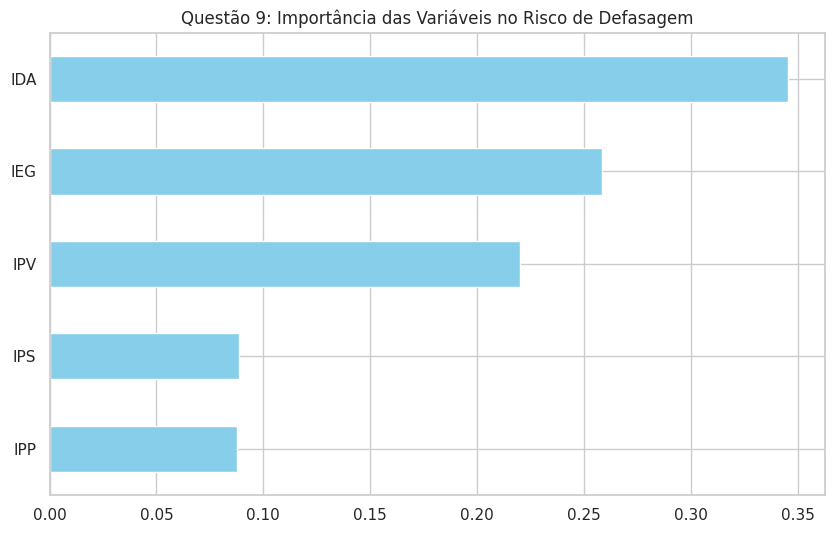

In [9]:
# --- PREPARAÇÃO FINAL PARA O MODELO ---

# 1. Definir o Alvo (y) - Exemplo: Alunos com INDE abaixo da mediana são 'Risco'
mediana_inde = df_base['INDE'].median()
df_base['RISCO'] = (df_base['INDE'] < mediana_inde).astype(int)

# 2. Definir as Features (X)
features_modelo = ['IDA', 'IEG', 'IPS', 'IPP', 'IPV']
X = df_base[features_modelo].fillna(df_base[features_modelo].median())
y = df_base['RISCO']

# 3. Treinar
from sklearn.ensemble import RandomForestClassifier
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X, y)

# Questão Nove
plt.figure(figsize=(10, 6))
importancias = pd.Series(modelo.feature_importances_, index=features_modelo)
importancias.sort_values().plot(kind='barh', color='skyblue')
plt.title('Questão 9: Importância das Variáveis no Risco de Defasagem')
plt.show()